In [1]:
!pip install deap

DEPRECATION: Loading egg at c:\users\user\.conda\envs\pygame_env\lib\site-packages\future-1.0.0-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\user\.conda\envs\pygame_env\lib\site-packages\pke-2.0.0-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\user\.conda\envs\pygame_env\lib\site-packages\unidecode-1.3.8-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [2]:
# Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score
from deap import base, creator, tools, algorithms
import random

In [3]:
# Download NLTK data (run this once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
# Load the dataset
df = pd.read_csv('data.csv')


In [5]:
# Preprocessing Function
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization and Stemming
    lemmatizer = WordNetLemmatizer()
    stemmer = PorterStemmer()

    tokens = [lemmatizer.lemmatize(word) for word in tokens]  # Lemmatization
    tokens = [stemmer.stem(word) for word in tokens]  # Stemming

    # Join tokens back into a string
    processed_text = ' '.join(tokens)
    return processed_text

# Apply preprocessing to the 'email' column
df['processed_email'] = df['email'].apply(preprocess_text)


In [6]:
# Feature Extraction: Using TF-IDF for email content
vectorizer = TfidfVectorizer(max_features=5000)  # Bag of words with max 5000 features
X = vectorizer.fit_transform(df['processed_email']).toarray()  # Transform processed emails into feature vectors
y = df['label']  # Labels: 0 or 1


In [7]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [8]:
# Genetic Algorithm to optimize Random Forest hyperparameters
def evaluate_individual(individual):
    n_estimators = individual[0]
    max_depth = individual[1]
    min_samples_split = individual[2]

    # Define the Random Forest model with given hyperparameters
    rf_model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth,
                                      min_samples_split=min_samples_split, random_state=42)

    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    return (accuracy,)

# Setup Genetic Algorithm with DEAP
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)


In [9]:
# Hyperparameter ranges for Genetic Algorithm
toolbox = base.Toolbox()
toolbox.register("attr_n_estimators", random.randint, 50, 500)  # Number of trees
toolbox.register("attr_max_depth", random.randint, 5, 50)       # Maximum depth
toolbox.register("attr_min_samples_split", random.randint, 2, 20)  # Min samples split

toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.attr_n_estimators, toolbox.attr_max_depth, toolbox.attr_min_samples_split), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutUniformInt, low=[50, 5, 2], up=[500, 50, 20], indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", evaluate_individual)


In [10]:
# Parameters for the genetic algorithm
population_size = 20
num_generations = 10
cx_prob = 0.5  # Probability for mating (crossover)
mut_prob = 0.2  # Probability for mutation

# Run Genetic Algorithm
population = toolbox.population(n=population_size)
algorithms.eaSimple(population, toolbox, cxpb=cx_prob, mutpb=mut_prob, ngen=num_generations, verbose=True)

# Get the best individual
best_individual = tools.selBest(population, k=1)[0]
print(f"Best Hyperparameters (Genetic Algorithm): {best_individual}")


gen	nevals
0  	20    
1  	11    
2  	9     
3  	13    
4  	8     
5  	15    
6  	8     
7  	13    
8  	16    
9  	15    
10 	10    
Best Hyperparameters (Genetic Algorithm): [330, 47, 2]


In [11]:
# Evaluate the final Random Forest model with the best hyperparameters
n_estimators, max_depth, min_samples_split = best_individual


In [12]:
best_rf_model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, min_samples_split=min_samples_split, random_state=42)
best_rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=47, n_estimators=330, random_state=42)

In [13]:
# Predictions
y_pred_rf = best_rf_model.predict(X_test)


In [14]:
# Accuracy, Precision, Recall, F1 Score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Print the values
print(f"Optimized Random Forest Accuracy (Genetic Algorithm): {accuracy_rf:.4f}")
print(f"Optimized Random Forest Precision: {precision_rf:.4f}")
print(f"Optimized Random Forest Recall: {recall_rf:.4f}")
print(f"Optimized Random Forest F1-Score: {f1_rf:.4f}")


Optimized Random Forest Accuracy (Genetic Algorithm): 0.9783
Optimized Random Forest Precision: 0.9637
Optimized Random Forest Recall: 0.9939
Optimized Random Forest F1-Score: 0.9785


C:\Users\user\AppData\Local\Temp\ipykernel_2728\2465503532.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Score', data=metrics_df_rf, palette='Blues_d')


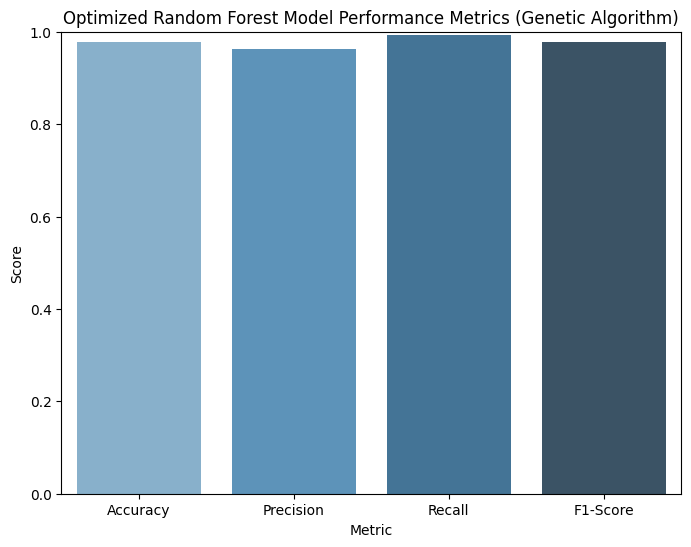

In [15]:
# Create a dataframe for plotting metrics
metrics_df_rf = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy_rf, precision_rf, recall_rf, f1_rf]
})

# Plot the metrics
plt.figure(figsize=(8, 6))
sns.barplot(x='Metric', y='Score', data=metrics_df_rf, palette='Blues_d')
plt.ylim(0, 1)
plt.title('Optimized Random Forest Model Performance Metrics (Genetic Algorithm)')
plt.ylabel('Score')
plt.show()

Confusion Matrix:
[[3024  117]
 [  19 3102]]


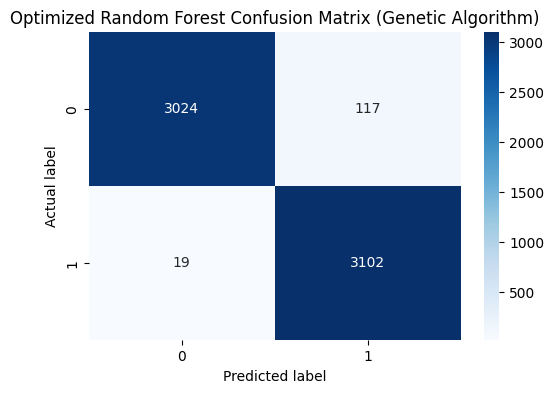

In [16]:
# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(conf_matrix_rf)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Optimized Random Forest Confusion Matrix (Genetic Algorithm)')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()


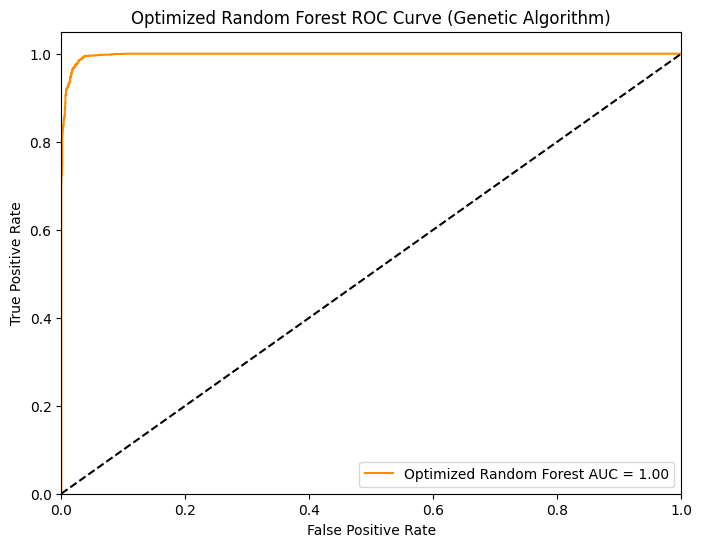

In [17]:
# ROC Curve
y_pred_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Optimized Random Forest AUC = {roc_auc_rf:.2f}', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--')  # Random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Optimized Random Forest ROC Curve (Genetic Algorithm)')
plt.legend(loc='lower right')
plt.show()